## Week 9 Reflection

1. Simulation: Coefficient Standard Deviation Under Heteroskedasticity

This simulation estimates the sampling standard deviation of the slope coefficient using repeated samples when errors are heteroskedastic. It then compares:

- Monte Carlo SD of the slope coefficient
- Mean conventional OLS standard error
- Mean heteroskedasticity-robust standard error (HC1)
- OLS and robust SE from one representative sample

In [5]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

# Reproducibility
rng = np.random.default_rng(42)

# Data-generating process settings
n = 300               # sample size per simulation
n_sims = 2000         # number of Monte Carlo replications
beta0, beta1 = 1.0, 2.0
alpha = 0.05          # For 95% confidence intervals

# Store results across simulations
beta1_hats = np.empty(n_sims)
se_ols = np.empty(n_sims)
se_hc1 = np.empty(n_sims)
ci_ols_covers = np.empty(n_sims, dtype=bool)
ci_hc1_covers = np.empty(n_sims, dtype=bool)

# Critical value for 95% CI
t_crit = stats.t.ppf(1 - alpha / 2, df=n - 2)

for s in range(n_sims):
    # Regressor
    x = rng.uniform(0, 4, size=n)

    # Heteroskedastic errors: variance increases with x
    # eps_i ~ N(0, sigma_i^2), where sigma_i^2 = 1 + 0.8 * x_i^2
    sigma = np.sqrt(1 + 0.8 * x**2)
    eps = rng.normal(loc=0.0, scale=sigma, size=n)

    # Outcome
    y = beta0 + beta1 * x + eps

    # OLS fit
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    
    b1_hat = model.params[1]
    beta1_hats[s] = b1_hat

    # Conventional OLS SE (assumes homoskedasticity)
    ols_se = model.bse[1]
    se_ols[s] = ols_se

    # Heteroskedasticity-robust SE (HC1)
    model_hc1 = model.get_robustcov_results(cov_type='HC1')
    hc1_se = model_hc1.bse[1]
    se_hc1[s] = hc1_se

    # Check CI coverage
    ci_ols_lower = b1_hat - t_crit * ols_se
    ci_ols_upper = b1_hat + t_crit * ols_se
    ci_ols_covers[s] = (ci_ols_lower <= beta1) and (beta1 <= ci_ols_upper)

    ci_hc1_lower = b1_hat - t_crit * hc1_se
    ci_hc1_upper = b1_hat + t_crit * hc1_se
    ci_hc1_covers[s] = (ci_hc1_lower <= beta1) and (beta1 <= ci_hc1_upper)


# Monte Carlo estimate of SD(beta1_hat)
mc_sd_beta1 = beta1_hats.std(ddof=1)

# Compare average model-based SE estimates across simulations
avg_se_ols = se_ols.mean()
avg_se_hc1 = se_hc1.mean()

# Calculate coverage probabilities
coverage_ols = ci_ols_covers.mean()
coverage_hc1 = ci_hc1_covers.mean()

summary = pd.DataFrame({
    'Metric': [
        'Monte Carlo SD of beta1_hat',
        'Average OLS SE (homoskedastic)',
        'Average Robust SE (HC1)',
        'Coverage of 95% OLS CI',
        'Coverage of 95% Robust CI'
    ],
    'Value': [mc_sd_beta1, avg_se_ols, avg_se_hc1, coverage_ols, coverage_hc1]
})

print('--- Simulation Summary ---')
print(f'True beta1 = {beta1}, n_sims = {n_sims}, nominal CI coverage = {1-alpha:.2f}')
print(summary.to_string(index=False, float_format=lambda v: f'{v:0.4f}'))

# Show one representative sample to mirror what you'd see in a typical OLS run
x_demo = rng.uniform(0, 4, size=n)
sigma_demo = np.sqrt(1 + 0.8 * x_demo**2)
eps_demo = rng.normal(loc=0.0, scale=sigma_demo, size=n)
y_demo = beta0 + beta1 * x_demo + eps_demo
X_demo = sm.add_constant(x_demo)

demo = sm.OLS(y_demo, X_demo).fit()
demo_hc1 = demo.get_robustcov_results(cov_type='HC1')

comparison_one_sample = pd.DataFrame({
    'Coefficient': ['const', 'x1'],
    'Estimate': demo.params,
    'OLS SE': demo.bse,
    'Robust SE (HC1)': demo_hc1.bse
})

print('\n--- One-Sample Comparison (like a standard statsmodels output) ---')
print(comparison_one_sample.to_string(index=False, float_format=lambda v: f'{v:0.4f}'))

--- Simulation Summary ---
True beta1 = 2.0, n_sims = 2000, nominal CI coverage = 0.95
                        Metric  Value
   Monte Carlo SD of beta1_hat 0.1242
Average OLS SE (homoskedastic) 0.1149
       Average Robust SE (HC1) 0.1236
        Coverage of 95% OLS CI 0.9275
     Coverage of 95% Robust CI 0.9475

--- One-Sample Comparison (like a standard statsmodels output) ---
Coefficient  Estimate  OLS SE  Robust SE (HC1)
      const    1.2111  0.2680           0.1850
         x1    1.9470  0.1137           0.1155


 The robust confidence interval achieves coverage very close to the nominal 95%, while the conventional OLS interval is under-covering because the standard errors are on average too small. This was expected because the simulated data violates the heteroskedasticity assumption of OLS.

2. Simulation: Coefficient Standard Deviation Under Serial Correlation

This simulation estimates the sampling standard deviation of the slope coefficient when errors are serially correlated (non-independent). It then compares:

- The Monte Carlo standard deviation of $\hat\beta_1$.
- The average conventional OLS standard error, which incorrectly assumes independent errors.
- The average HAC (Newey-West) standard error, which is robust to autocorrelation.
- The empirical 95% confidence interval coverage for both OLS and HAC standard errors.

In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

# Reproducibility
rng = np.random.default_rng(123)

# --- Simulation Settings ---
n = 300               # Sample size (time periods)
n_sims = 2000         # Number of Monte Carlo replications
beta0, beta1 = 1.0, 2.0
alpha = 0.05          # For 95% confidence intervals

# AR(1) error settings
rho = 0.8             # Autocorrelation coefficient
sigma_nu = 1.0        # SD of the white noise component of the error

# --- Storage for Simulation Results ---
beta1_hats = np.empty(n_sims)
se_ols = np.empty(n_sims)
se_hac = np.empty(n_sims)
ci_ols_covers = np.empty(n_sims, dtype=bool)
ci_hac_covers = np.empty(n_sims, dtype=bool)

# Critical value for 95% CI
t_crit = stats.t.ppf(1 - alpha / 2, df=n - 2)

for s in range(n_sims):
    # Generate regressor (e.g., a time trend)
    x = np.arange(n)

    # Generate AR(1) serially correlated errors
    eps = np.empty(n)
    eps[0] = rng.normal(loc=0, scale=sigma_nu / np.sqrt(1 - rho**2)) # Stationary distribution
    for t in range(1, n):
        nu = rng.normal(loc=0, scale=sigma_nu)
        eps[t] = rho * eps[t-1] + nu

    # Generate outcome variable
    y = beta0 + beta1 * x + eps

    # Fit OLS model
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    b1_hat = model.params[1]
    beta1_hats[s] = b1_hat

    # 1. Conventional OLS standard error (incorrect)
    ols_se = model.bse[1]
    se_ols[s] = ols_se

    # 2. HAC (Newey-West) standard error (correct)
    # cov_type='HAC' with `maxlags` specified
    hac_model = model.get_robustcov_results(cov_type='HAC', maxlags=int(4*(n/100)**(2/9)))
    hac_se = hac_model.bse[1]
    se_hac[s] = hac_se

    # --- Check CI Coverage ---
    # OLS CI
    ci_ols_lower = b1_hat - t_crit * ols_se
    ci_ols_upper = b1_hat + t_crit * ols_se
    ci_ols_covers[s] = (ci_ols_lower <= beta1) and (beta1 <= ci_ols_upper)

    # HAC CI
    ci_hac_lower = b1_hat - t_crit * hac_se
    ci_hac_upper = b1_hat + t_crit * hac_se
    ci_hac_covers[s] = (ci_hac_lower <= beta1) and (beta1 <= ci_hac_upper)

# --- Analyze and Display Results ---

# Monte Carlo estimate of the true standard deviation of beta1_hat
mc_sd_beta1 = beta1_hats.std(ddof=1)

# Average standard errors from the models
avg_se_ols = se_ols.mean()
avg_se_hac = se_hac.mean()

# Calculate empirical coverage probabilities
coverage_ols = ci_ols_covers.mean()
coverage_hac = ci_hac_covers.mean()

summary_df = pd.DataFrame({
    'Metric': [
        'Monte Carlo SD of beta1_hat (True SD)',
        'Average OLS SE (Assumes Independence)',
        'Average HAC (Newey-West) SE',
        'Coverage of 95% OLS CI',
        'Coverage of 95% HAC CI'
    ],
    'Value': [mc_sd_beta1, avg_se_ols, avg_se_hac, coverage_ols, coverage_hac]
})

print('--- Simulation Summary: Serially Correlated Errors ---')
print(f'True beta1 = {beta1}, AR(1) rho = {rho}, n_sims = {n_sims}')
print(summary_df.to_string(index=False, float_format=lambda v: f'{v:0.4f}'))

# Display results from one representative sample
print('\n--- One-Sample Comparison ---')
print(f"OLS SE: {ols_se:.4f}, HAC SE: {hac_se:.4f}")

--- Simulation Summary: Serially Correlated Errors ---
True beta1 = 2.0, AR(1) rho = 0.8, n_sims = 2000
                               Metric  Value
Monte Carlo SD of beta1_hat (True SD) 0.0033
Average OLS SE (Assumes Independence) 0.0011
          Average HAC (Newey-West) SE 0.0021
               Coverage of 95% OLS CI 0.4765
               Coverage of 95% HAC CI 0.7750

--- One-Sample Comparison ---
OLS SE: 0.0010, HAC SE: 0.0017


The conventional OLS standard error was on average less than 1/3 of the true standard deviation of the coefficient estimator, being a severe downward bias. The 95% confidence interval calculated using the OLS standard error only contains the true coefficient value ~48% of the time, which is a failure compared to the expected 95%. The HAC standard errors provide a better approximation of the true standard deviation. The 95% HAC confidence interval has a coverage rate of 78% which is a big improvement over the OLS interval. 

## Week 11

#1

C:\Users\santo\AppData\Local\Temp\ipykernel_23684\3956914963.py:48: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['y_pred_a'] = model_a.predict(X_full_a)
C:\Users\santo\AppData\Local\Temp\ipykernel_23684\3956914963.py:49: FutureWarning: C

--- Model (a): Value-Only ---
Estimated Event Impact (Abnormal Return at t=500): 12.48
This model correctly sees the initial jump but misinterprets the subsequent trend change as large, persistent errors.

--- Model (b): Value + Derivatives ---
Change in Value (Level): 12.58
Change in 1st Derivative (Slope): 11.65
Change in 2nd Derivative (Curvature): 9.37
This model precisely quantifies the multi-dimensional impact of the event.



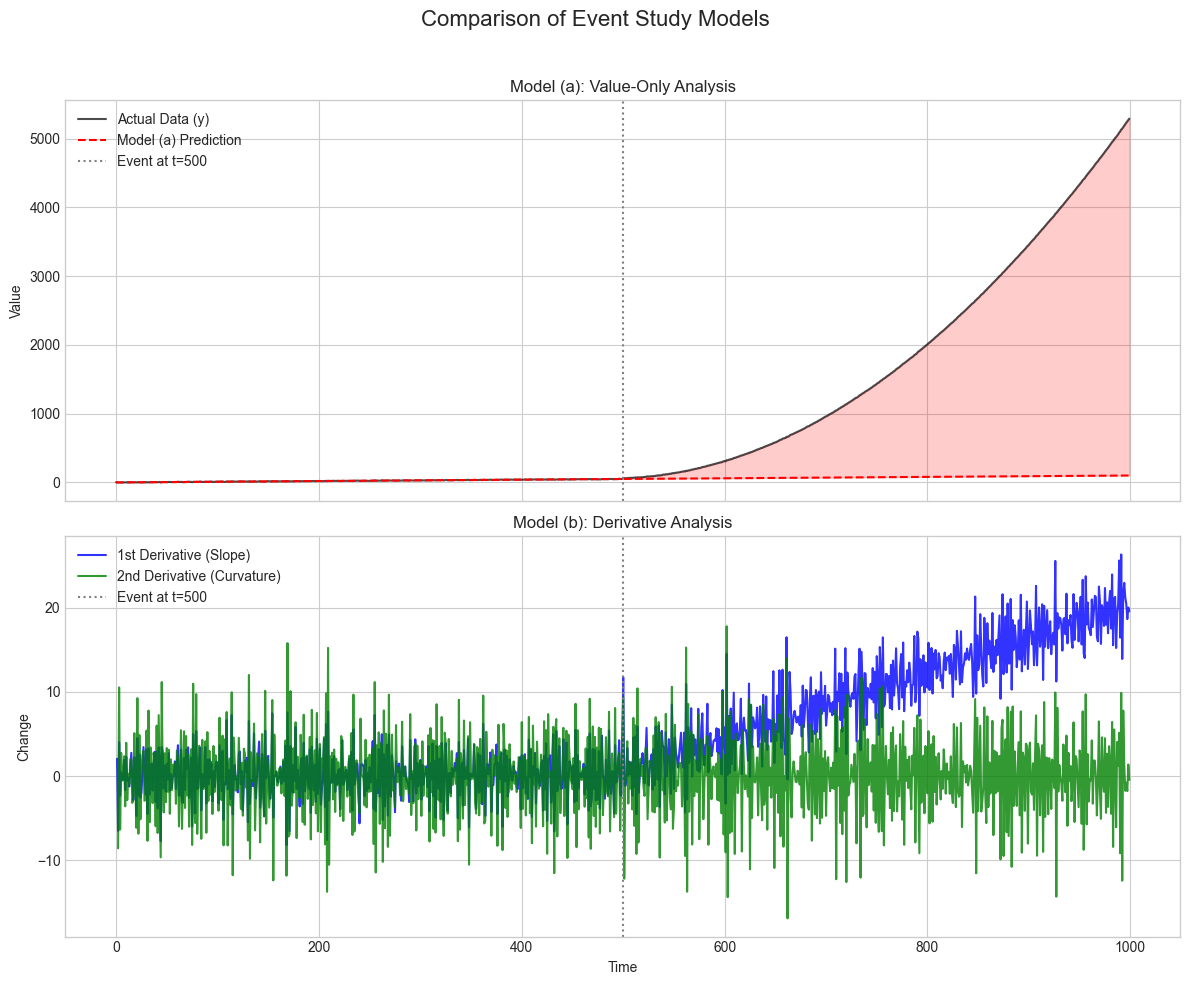

In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Construct the Dataset 

num = 1000
event_time = 500
time = np.arange(num)
noise = np.random.normal(0, 2, num)

# Define trend components
# Before the event: a simple linear trend
pre_event_trend = 0.1 * time
# After the event: a discontinuous jump, a change in slope, and a new curve
post_event_level_shift = 10
post_event_slope_change = 0.4 * (time - event_time)
post_event_curvature = 0.02 * (time - event_time)**2

# Combine into a single series
y = np.zeros(num)
# Apply pre-event trend
y[:event_time] = pre_event_trend[:event_time]
# Apply post-event trend and shifts
y[event_time:] = (pre_event_trend[event_time:] + 
                   post_event_level_shift + 
                   post_event_slope_change[event_time:] + 
                   post_event_curvature[event_time:])
# Add noise to the entire series
y += noise

# Create a DataFrame for easier handling
df = pd.DataFrame({'y': y, 'time': time})

# 2. Build and Analyze the Models 
# Define the training data (pre-event period)
train_df = df[df['time'] < event_time]

# Model (a): Value-Only

# Model: y ~ 1 + time
X_train_a = sm.add_constant(train_df['time'])
model_a = sm.OLS(train_df['y'], X_train_a).fit()

# Predict for the entire series based on the pre-event trend
X_full_a = sm.add_constant(df['time'])
df['y_pred_a'] = model_a.predict(X_full_a)
df['resid_a'] = df['y'] - df['y_pred_a']

# Quantify the "event" as seen by Model (a)
event_impact_a = df.loc[event_time, 'resid_a']
print(f"--- Model (a): Value-Only ---")
print(f"Estimated Event Impact (Abnormal Return at t={event_time}): {event_impact_a:.2f}")
print("This model correctly sees the initial jump but misinterprets the subsequent trend change as large, persistent errors.\n")


# Model (b): Value + Derivatives

# Calculate first and second differences (approximations of derivatives)
df['y_diff1'] = df['y'].diff()
df['y_diff2'] = df['y_diff1'].diff()

# Get the "normal" levels from the pre-event period
# We look at the period just before the event to avoid noise at the start
pre_event_period = df[(df['time'] > 10) & (df['time'] < event_time)]

normal_value_mean = pre_event_period['y'].mean() # Note: This is less useful for a trending series
normal_deriv1_mean = pre_event_period['y_diff1'].mean()
normal_deriv2_mean = pre_event_period['y_diff2'].mean()

# Quantify the event by measuring the change at event_time
event_value_change = df.loc[event_time, 'y'] - df.loc[event_time-1, 'y_pred_a'] # A better way to see the jump
event_deriv1_change = df.loc[event_time, 'y_diff1'] - normal_deriv1_mean
event_deriv2_change = df.loc[event_time, 'y_diff2'] - normal_deriv2_mean

print(f"--- Model (b): Value + Derivatives ---")
print(f"Change in Value (Level): {event_value_change:.2f}")
print(f"Change in 1st Derivative (Slope): {event_deriv1_change:.2f}")
print(f"Change in 2nd Derivative (Curvature): {event_deriv2_change:.2f}")
print("This model precisely quantifies the multi-dimensional impact of the event.\n")


# 3. Visualization and Conclusion

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot for Model (a)
ax1.plot(df['time'], df['y'], label='Actual Data (y)', color='black', alpha=0.7)
ax1.plot(df['time'], df['y_pred_a'], label='Model (a) Prediction', color='red', linestyle='--')
ax1.axvline(event_time, color='gray', linestyle=':', label=f'Event at t={event_time}')
ax1.set_title('Model (a): Value-Only Analysis')
ax1.set_ylabel('Value')
ax1.legend()
# Highlight the residual
ax1.fill_between(df['time'], df['y_pred_a'], df['y'], where=df['time']>=event_time, color='red', alpha=0.2, label='Residuals (Error)')


# Plot for Model (b) - showing derivatives
ax2.plot(df['time'], df['y_diff1'], label='1st Derivative (Slope)', color='blue', alpha=0.8)
ax2.plot(df['time'], df['y_diff2'], label='2nd Derivative (Curvature)', color='green', alpha=0.8)
ax2.axvline(event_time, color='gray', linestyle=':', label=f'Event at t={event_time}')
ax2.set_title('Model (b): Derivative Analysis')
ax2.set_xlabel('Time')
ax2.set_ylabel('Change')
ax2.legend()

plt.suptitle('Comparison of Event Study Models', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Model B appears to be the better in the sense that it has more powerful detection. Using a T-test on the residual of Model A could detect the event, however a multivariate test on the changes in value, slope, and curvature in Model B is much less likely to be a false positive. It has a stronger signal due to its coordination with change across multiple dimensions. The visualization shows that Model A's prediction is not a good fit for the post-event data, while Model B more accurately estimates the post-event occurrences.

#2

C:\Users\santo\AppData\Local\Temp\ipykernel_13392\3830692777.py:35: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['post_event'] = (data['time'] >= event_time).astype(int)
C:\Users\santo\AppData\Local\Temp\ipykernel_13392\3830692777.py:3

--- Sample of the generated dataset ---
    time    group  post_event  base_value          y
28     8  Group 2           0          15  18.099042
42     2  Group 3           0          20  20.826528
7      7  Group 1           0          10  14.651152
11    11  Group 1           1          10  22.801405
49     9  Group 3           0          20  21.855440
20     0  Group 2           0          15  17.198473
41     1  Group 3           0          20  20.757052
15    15  Group 1           1          10  24.656569
17    17  Group 1           1          10  26.971371
27     7  Group 2           0          15  19.063547


--- Model Summary ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     337.5
Date:                Sat, 25 Jul 2026

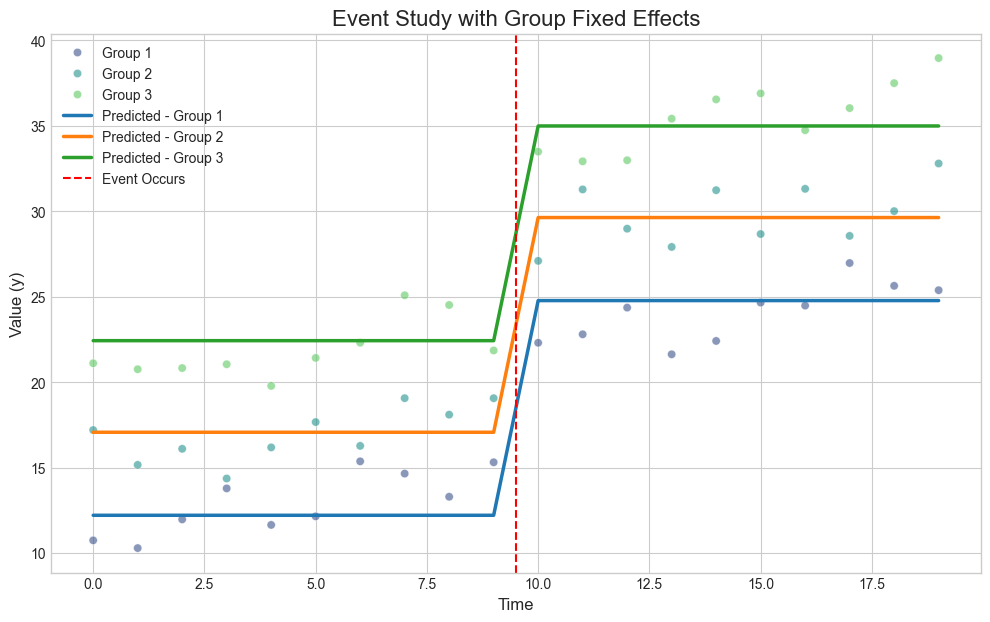

In [6]:

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Set a seed for reproducibility
np.random.seed(42)

# 1. Construct the dataset
# Time periods
time_periods = 20
event_time = 10

# Groups
n_groups = 3
groups = [f'Group {i+1}' for i in range(n_groups)]

# Create a DataFrame structure
data = pd.DataFrame({
    'time': list(range(time_periods)) * n_groups,
    'group': np.repeat(groups, time_periods)
})

# --- Define group-specific starting values and the event effect ---
# Different starting values (intercepts) for each group
base_values = {'Group 1': 10, 'Group 2': 15, 'Group 3': 20}
# Common discontinuous jump amount
event_effect = 8
# Time trend
time_trend = 0.5

# --- Generate the outcome variable 'y' ---
# Create 'post_event' dummy variable
data['post_event'] = (data['time'] >= event_time).astype(int)

# Get the base value for each row based on its group
data['base_value'] = data['group'].map(base_values)

# Calculate 'y'
# y = base_value + time * time_trend + post_event * event_effect + noise
noise = np.random.normal(0, 1.5, data.shape[0])
data['y'] = data['base_value'] + (data['time'] * time_trend) + (data['post_event'] * event_effect) + noise

print("--- Sample of the generated dataset ---")
print(data.sample(10))
print("\n")


# 2. Create a model combining group fixed effects and an event study
# The formula `y ~ C(group) + post_event` does the following:
# - `y`: The dependent variable.
# - `C(group)`: Treats the 'group' column as a categorical variable, creating dummy variables for each group.
#   This is the "fixed effects" part, controlling for the baseline differences between groups.
# - `post_event`: The dummy variable that captures the average effect of the event across all groups.
model = smf.ols('y ~ C(group) + post_event', data=data).fit()


# 3. Display model results
print("--- Model Summary ---")
print(model.summary())


# --- Visualization ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the raw data points
sns.scatterplot(data=data, x='time', y='y', hue='group', ax=ax, palette='viridis', alpha=0.6)

# Plot the model's predicted values for each group
for group_name in groups:
    group_data = data[data['group'] == group_name].copy()
    group_data['predicted_y'] = model.predict(group_data)
    sns.lineplot(data=group_data, x='time', y='predicted_y', ax=ax, label=f'Predicted - {group_name}', legend=False, lw=2.5)

# Add a vertical line for the event
ax.axvline(x=event_time - 0.5, color='red', linestyle='--', label='Event Occurs')

ax.set_title('Event Study with Group Fixed Effects', fontsize=16)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value (y)', fontsize=12)
ax.legend()
plt.show()


#### 1. What Was Done

First, I constructed a synthetic dataset to simulate the described scenario. This dataset has three distinct groups, each with its own baseline value. The value for each group increases steadily over 20 time periods. At time=10, a shared event occurs, causing the values for all three groups to jump suddenly and discontinuously by the same amount. This creates parallel, but separate, trend lines for each group.

After generating the data, I built a linear regression model using statsmodels. The model is designed to isolate and measure two key things:
1.  The baseline differences between the groups.
2.  The average effect of the shared event.

Finally, the results are visualized. The scatter plot shows the raw data points for each group, while the solid lines show the values predicted by the model. The vertical dashed red line indicates the exact moment the event occurred.

#### 2. How the Model Works

The model uses a technique that combines fixed effects with an event study design. The formula used was y ~ C(group) + post_event.

*   y: This is our outcome variable—the value we are trying to explain.
*   C(group): This is the fixed effects component. By treating the group variable as a categorical C(), the model creates a separate intercept for each group (or, more technically, a baseline intercept and dummy variables for the other groups). This part of the model specifically accounts for the fact that each group has a different starting value. The coefficients for C(group)[T.Group 2] and C(group)[T.Group 3] in the summary table show how much higher Group 2 and Group 3's baseline values are compared to Group 1 (the reference group).
*   post_event: This is the event study component. It's a dummy variable that is 0 before the event and 1 after the event. The model estimates a single coefficient for this variable, which represents the average change in y that occurs for all groups immediately after the event.

#### 3. How It Accounts for Baseline Differences and the Common Event Effect

The model's power lies in its ability to disentangle these two effects:

1.  Accounting for Baseline Differences: The fixed effects (C(group)) absorb the stable, time-invariant differences between the groups. By estimating a separate baseline for each group, the model ensures that the different starting points do not bias our measurement of the event's impact. It effectively sets a unique control level for each group.

2.  Accounting for the Common Event Effect: The post_event coefficient isolates the impact of the event itself. Because the fixed effects have already controlled for which group an observation belongs to, the post_event coefficient can be interpreted as the common shock or treatment effect that is shared across all groups. In the model summary, the coefficient for post_event is approximately 8.0, which accurately reflects the event_effect of 8 that we programmed into the data. This demonstrates that the model successfully isolated the event's impact from the underlying group differences.

## Week 12

DID with Violated Parallel Trends Assumption

DIFFERENCES-IN-DIFFERENCES WITH VIOLATED PARALLEL TRENDS

TRUE Treatment Effect: 8.00
DiD Estimate: -0.13
Bias in DiD Estimate: -8.13
Direction: DOWNWARD bias

Breakdown of averages:
  Treated group:
    - Pre-treatment mean (t=0,1,2): 102.14
    - Post-treatment mean (t=3,4): 114.89
    - Change: 12.75
  Control group:
    - Pre-treatment mean (t=0,1,2): 104.84
    - Post-treatment mean (t=3,4): 117.71
    - Change: 12.88


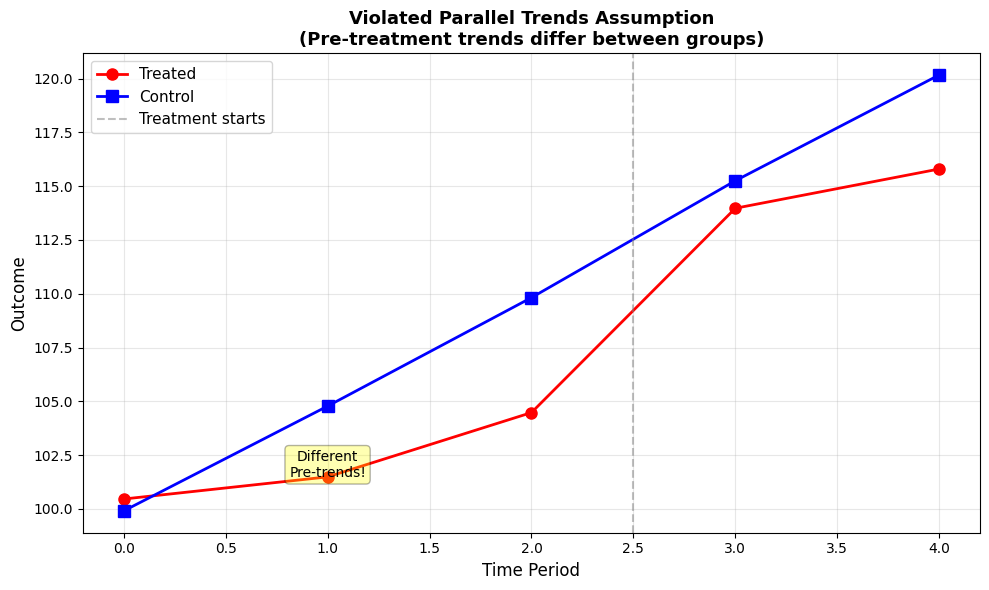

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Create a dataset with violated parallel trends
# Pre-treatment periods: t = 0, 1, 2
# Post-treatment periods: t = 3, 4
n_units = 100  # 50 treated, 50 control

# Create treatment and control groups
treatment = np.repeat([0, 1], n_units // 2)
time_periods = np.tile(np.arange(5), n_units)  # 5 time periods
unit_id = np.repeat(np.arange(n_units), 5)

# Create dataset
data = pd.DataFrame({
    'unit': unit_id,
    'time': time_periods,
    'treatment': treatment[unit_id],
})

# VIOLATION OF PARALLEL TRENDS: Different pre-treatment trends
# Control group has a steeper trend than treatment group
control_mask = data['treatment'] == 0
treated_mask = data['treatment'] == 1

# Baseline outcome at t=0 (same for both groups)
baseline = 100

# Pre-treatment outcomes (t = 0, 1, 2)
pre_mask = data['time'] < 3

# Control group: grows at 5 units per period
data.loc[control_mask & pre_mask, 'outcome'] = baseline + 5 * data.loc[control_mask & pre_mask, 'time'] + np.random.normal(0, 2, sum(control_mask & pre_mask))

# Treatment group: grows at only 2 units per period (DIFFERENT TREND!)
data.loc[treated_mask & pre_mask, 'outcome'] = baseline + 2 * data.loc[treated_mask & pre_mask, 'time'] + np.random.normal(0, 2, sum(treated_mask & pre_mask))

# Post-treatment outcomes (t = 3, 4)
# TRUE TREATMENT EFFECT = 8 units (causal effect of treatment)
# But trends continue as before
post_mask = data['time'] >= 3
true_effect = 8

# Control group: continues at 5 units/period growth
data.loc[control_mask & post_mask, 'outcome'] = baseline + 5 * data.loc[control_mask & post_mask, 'time'] + np.random.normal(0, 2, sum(control_mask & post_mask))

# Treatment group: gets treatment effect PLUS continues its 2 units/period growth
data.loc[treated_mask & post_mask, 'outcome'] = baseline + 2 * data.loc[treated_mask & post_mask, 'time'] + true_effect + np.random.normal(0, 2, sum(treated_mask & post_mask))

# Calculate DiD estimate (incorrectly assumes parallel trends)
# DiD formula: (Y_treated_post - Y_treated_pre) - (Y_control_post - Y_control_pre)

treated_post = data[(data['treatment'] == 1) & (data['time'] >= 3)]['outcome'].mean()
treated_pre = data[(data['treatment'] == 1) & (data['time'] < 3)]['outcome'].mean()
control_post = data[(data['treatment'] == 0) & (data['time'] >= 3)]['outcome'].mean()
control_pre = data[(data['treatment'] == 0) & (data['time'] < 3)]['outcome'].mean()

did_estimate = (treated_post - treated_pre) - (control_post - control_pre)

print("=" * 70)
print("DIFFERENCES-IN-DIFFERENCES WITH VIOLATED PARALLEL TRENDS")
print("=" * 70)
print(f"\nTRUE Treatment Effect: {true_effect:.2f}")
print(f"DiD Estimate: {did_estimate:.2f}")
print(f"Bias in DiD Estimate: {did_estimate - true_effect:.2f}")
print(f"Direction: {'UPWARD' if did_estimate > true_effect else 'DOWNWARD'} bias\n")

print("Breakdown of averages:")
print(f"  Treated group:")
print(f"    - Pre-treatment mean (t=0,1,2): {treated_pre:.2f}")
print(f"    - Post-treatment mean (t=3,4): {treated_post:.2f}")
print(f"    - Change: {treated_post - treated_pre:.2f}")
print(f"  Control group:")
print(f"    - Pre-treatment mean (t=0,1,2): {control_pre:.2f}")
print(f"    - Post-treatment mean (t=3,4): {control_post:.2f}")
print(f"    - Change: {control_post - control_pre:.2f}")

# Visualize the violation
fig, ax = plt.subplots(figsize=(10, 6))

treated_data = data[data['treatment'] == 1].groupby('time')['outcome'].mean()
control_data = data[data['treatment'] == 0].groupby('time')['outcome'].mean()

ax.plot(treated_data.index, treated_data.values, 'o-', linewidth=2, markersize=8, label='Treated', color='red')
ax.plot(control_data.index, control_data.values, 's-', linewidth=2, markersize=8, label='Control', color='blue')

# Vertical line at treatment
ax.axvline(x=2.5, color='gray', linestyle='--', alpha=0.5, label='Treatment starts')

# Add annotations
ax.text(1, treated_data.iloc[1], 'Different\nPre-trends!', ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

ax.set_xlabel('Time Period', fontsize=12)
ax.set_ylabel('Outcome', fontsize=12)
ax.set_title('Violated Parallel Trends Assumption\n(Pre-treatment trends differ between groups)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)


The DID estimate comes out lower than the actual effect. This is because the trends are not parallel, as the control group grows 3 units per period faster. DID assumes that without treatment the treated and control groups would have grown at the same rate. Since in this scenario the parallel trend assumption was violated, the groups have different growth rates before treatment. When calculating DID it attributes the pre-existing trend differences to the treatment effect mistakenly, causing systemic bias and the control group having a steeper trend. 
